In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout

In [2]:
dataset_path = r"C:\Users\Manoj Kumar\OneDrive\Desktop\Garbage classification\Garbage classification"

print("Dataset path set:", dataset_path)
print("Classes found:", os.listdir(dataset_path))

Dataset path set: C:\Users\Manoj Kumar\OneDrive\Desktop\Garbage classification\Garbage classification
Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_height = 224
img_width = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [4]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


In [5]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 503 images belonging to 6 classes.


### Model Building using Convolutional Neural Network (CNN)

In [22]:
model = Sequential([

    # First Convolutional Layer
    Conv2D(
      32,(3,3),
      activation='relu',
      input_shape=(img_height,img_width,3)
    ),
    MaxPooling2D(2,2),

    # Second Convolutional Layer
    Conv2D(
      64,(3,3),
      activation='relu'
    ),
    MaxPooling2D(2,2),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128,activation='relu'),
    Dropout(0.5),

    # Output Layer
    Dense(6,activation='softmax')       
  ])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_data,
    validation_data = val_data,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.3019 - loss: 2.1383 - val_accuracy: 0.3956 - val_loss: 1.5598
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.4461 - loss: 1.3732 - val_accuracy: 0.3976 - val_loss: 1.5166
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5247 - loss: 1.2287 - val_accuracy: 0.4473 - val_loss: 1.3778
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.6097 - loss: 1.0437 - val_accuracy: 0.4056 - val_loss: 1.5047
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.6670 - loss: 0.8980 - val_accuracy: 0.4791 - val_loss: 1.3934


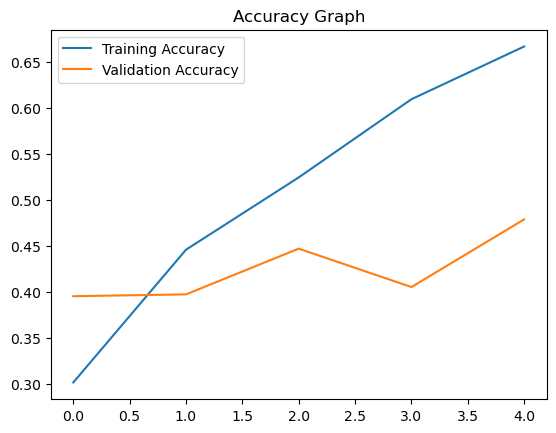

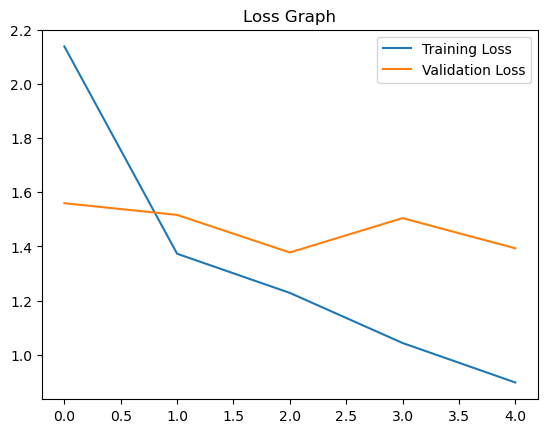

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Graph')
plt.show()

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.legend()
plt.title('Loss Graph')
plt.show()

In [29]:
model.save("garbage_classification_cnn_model.h5")

### Conclusion

In this project, a Convolutional Neural Network (CNN) model was developed to classify garbage images into six categories.
The model was trained using image data generators and showed reasonable performance on training data and validation data.
The results demonstrate that deep learning techniques can be applied to waste classification problems.
This project highlights the practical use of CNNs in image classification tasks.